# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

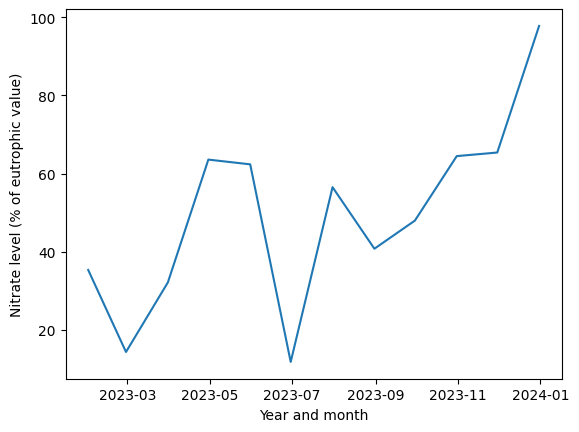

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

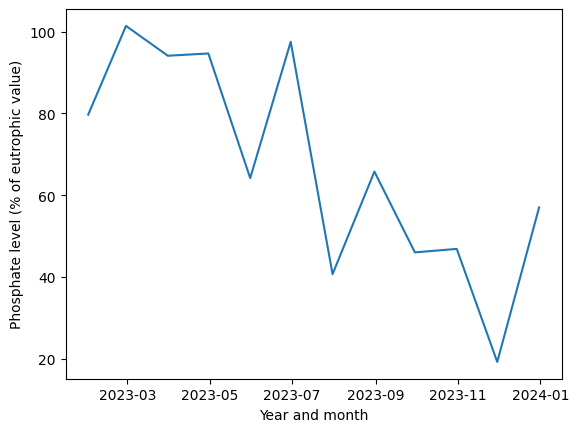

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

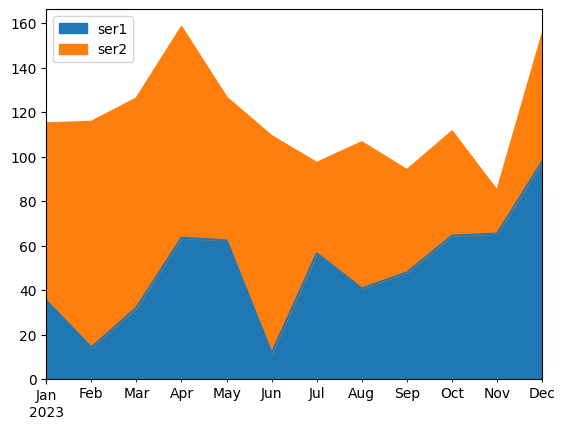

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

Using an area plot can help show the overall trend of nitrate and phosphate together over time. Since the values are stacked, it becomes easier to see the total nutrient level in the water sample and how each one contributes to that total. This can make patterns across the months more noticeable and helps show when one nutrient is higher than the other.

On the other hand, an area plot can also make it a little harder to see the exact value of each nutrient. Because phosphate is stacked on top of nitrate, you cannot read its value directly from the axis. You have to estimate it based on where the nitrate level ends, which can make comparisons less clear than if the two were shown as separate line graphs.

To improve the graphs, I would add a title so the viewer immediately knows what the chart is showing and rename the legend labels to Nitrate and Phosphate instead of ser1 and ser2. I would also use clearer colors and rotate the month labels slightly so they are easier to read. Small changes like that would make the graphs cleaner and easier to understand.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [5]:
df = pd.read_csv("EdStatsData.csv (2).zip")
df = df.drop(columns=["Unnamed: 69"], errors="ignore")

indicators = [
    "Adjusted net enrolment rate, lower secondary, both sexes (%)",
    "Adjusted net enrolment rate, lower secondary, female (%)"
]

subset = df[df["Indicator Name"].isin(indicators)]

us = subset[subset["Country Name"] == "United States"]

years = us.loc[:, "2000":"2014"].T
years.columns = us["Indicator Name"].values
years = years.dropna()

years.columns = [
    "Enrollment (Both Sexes)",
    "Enrollment (Female)"
]

                         Enrollment (Both Sexes)  Enrollment (Female)
Enrollment (Both Sexes)                 1.000000             0.636964
Enrollment (Female)                     0.636964             1.000000


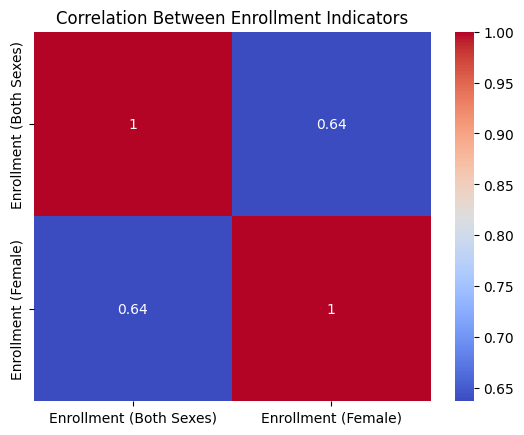

In [6]:
# Correlation 
import matplotlib.pyplot as plt

corr = years.corr()
print(corr)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Enrollment Indicators")
plt.show()

In [7]:
print(years.columns)

Index(['Enrollment (Both Sexes)', 'Enrollment (Female)'], dtype='str')


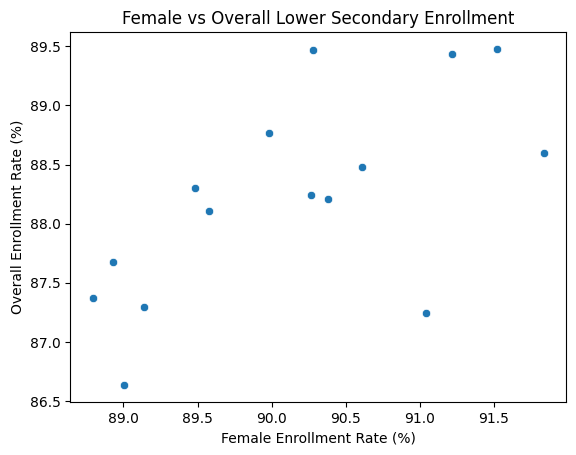

In [8]:
import matplotlib.pyplot as plt

sns.scatterplot(
    x=years["Enrollment (Female)"],
    y=years["Enrollment (Both Sexes)"]
)

plt.xlabel("Female Enrollment Rate (%)")
plt.ylabel("Overall Enrollment Rate (%)")
plt.title("Female vs Overall Lower Secondary Enrollment")

plt.show()

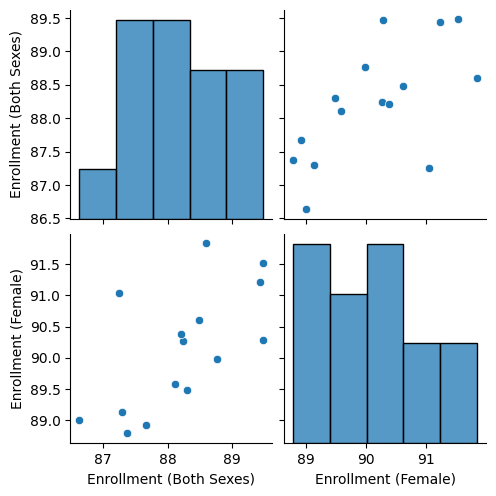

In [9]:
sns.pairplot(years)
plt.show()

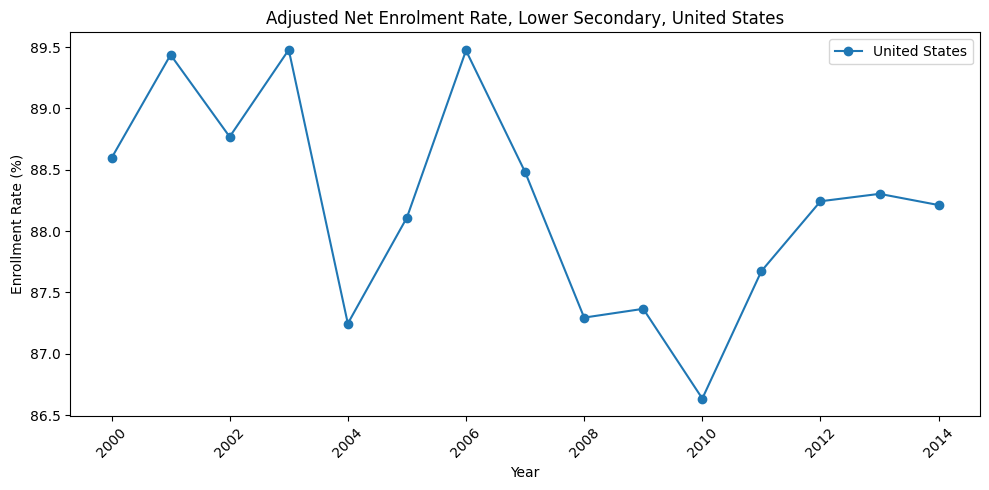

In [10]:
import matplotlib.pyplot as plt

import pandas as pd

df = pd.read_csv("EdStatsData.csv (2).zip")
df = df.drop(columns=["Unnamed: 69"], errors="ignore")

enrollment = df[df["Indicator Name"] == "Adjusted net enrolment rate, lower secondary, both sexes (%)"]
enrollment_clean = enrollment.dropna(subset=["2000", "2005", "2010", "2015", "2020"], how="all")

country = enrollment_clean[enrollment_clean["Country Name"] == "United States"]
country_years = country.loc[:, "2000":"2020"].T
country_years.columns = ["United States"]

country_years.plot(figsize=(10,5), marker="o")
plt.title("Adjusted Net Enrolment Rate, Lower Secondary, United States")
plt.xlabel("Year")
plt.ylabel("Enrollment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To make sense of this graph, I compared the Adjusted Net Enrollment Rate for Lower Secondary Schools for both sexes to the Adjusted Net Enrollment Rate for Lower Secondary Schools for females enrollment rate. The correlation shows a positive relationship between the two variables, which makes sense as female enrollment is a major component for enrollment rates overall. The scatterplots show a clear upward pattern showing that as female enrollment rate increases, so does overall enrollment rates. The pairplot confirmed the relationship and showed that the distribution of the two variables are similar. This line graph shows the Adjusted Net Enrollment Rate for  Lower Secondary Schools in the United States from 2000 to 2014 which is about 86.6% and 89.5%. From time to time, you will notice a small shifts but ultimately it is within the same range which shows consistency. One of the limitations with this dataset is that many of the earlier years are missing values, which forced us to work with more modern and recent data. The data appears to be usable in exploratory analysis.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

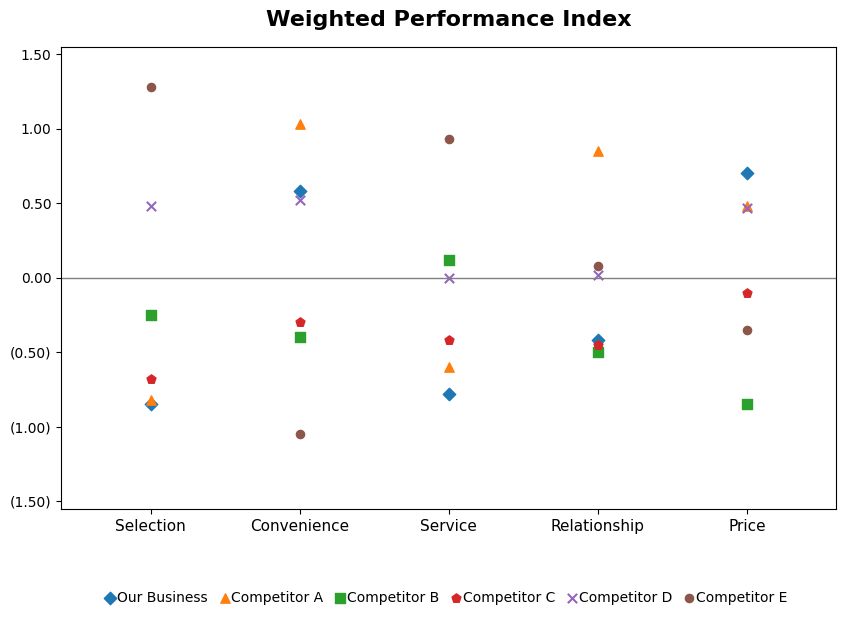

In [11]:
categories = ["Selection", "Convenience", "Service", "Relationship", "Price"]
x = np.arange(len(categories))

our_business = [-0.85, 0.58, -0.78, -0.42, 0.70]
competitor_a = [-0.82, 1.03, -0.60, 0.85, 0.48]
competitor_b = [-0.25, -0.40, 0.12, -0.50, -0.85]
competitor_c = [-0.68, -0.30, -0.42, -0.45, -0.10]
competitor_d = [0.48, 0.52, 0.00, 0.02, 0.47]
competitor_e = [1.28, -1.05, 0.93, 0.08, -0.35]

plt.figure(figsize=(10, 6))

plt.scatter(x, our_business, marker='D', s=40, label='Our Business')
plt.scatter(x, competitor_a, marker='^', s=45, label='Competitor A')
plt.scatter(x, competitor_b, marker='s', s=45, label='Competitor B')
plt.scatter(x, competitor_c, marker='p', s=45, label='Competitor C')
plt.scatter(x, competitor_d, marker='x', s=45, label='Competitor D')
plt.scatter(x, competitor_e, marker='o', s=35, label='Competitor E')

plt.axhline(0, color='gray', linewidth=1)

plt.xticks(x, categories, fontsize=11)
plt.yticks(
    [-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5],
    ["(1.50)", "(1.00)", "(0.50)", "0.00", "0.50", "1.00", "1.50"]
)

plt.ylim(-1.55, 1.55)
plt.xlim(-0.6, len(categories) - 0.4)

plt.title("Weighted Performance Index", fontsize=16, weight='bold', pad=15)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=6,
    frameon=False,
    handlelength=0,
    handletextpad=0.5,
    columnspacing=1.2
)